In [2]:
import os
import numpy as np
import pandas as pd
import scipy.io as sio
from scipy.io import wavfile
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
pasta_dados = '01'

def carregar_ficheiro(ficheiro, pasta_dados):
    
    caminho_completo = os.path.join(pasta_dados, ficheiro)
    componentes_nome = ficheiro.replace('.wav', '').split('_')
    
    if len(componentes_nome) != 3:
        return 1
    
    digito = int(componentes_nome[0])
    participante = componentes_nome[1]
    repeticao = int(componentes_nome[2])
    
    fs, sinal = wavfile.read(caminho_completo)
    
    return {
        'pasta_dados': pasta_dados,
        'ficheiro': ficheiro,
        'participante': participante,
        'digito': digito,
        'repeticao': repeticao,
        'taxa_amostragem': fs,
        'sinal': sinal
    }

dados_audio = []
for ficheiro in os.listdir(pasta_dados):
    if ficheiro.endswith('.wav'):
        novo = carregar_ficheiro(ficheiro, pasta_dados)
        if novo != 1:
            dados_audio.append(novo)

In [4]:
df = pd.DataFrame(dados_audio)
df = df.sort_values(by=['digito', 'repeticao']).reset_index(drop=True)
#display(df.head())

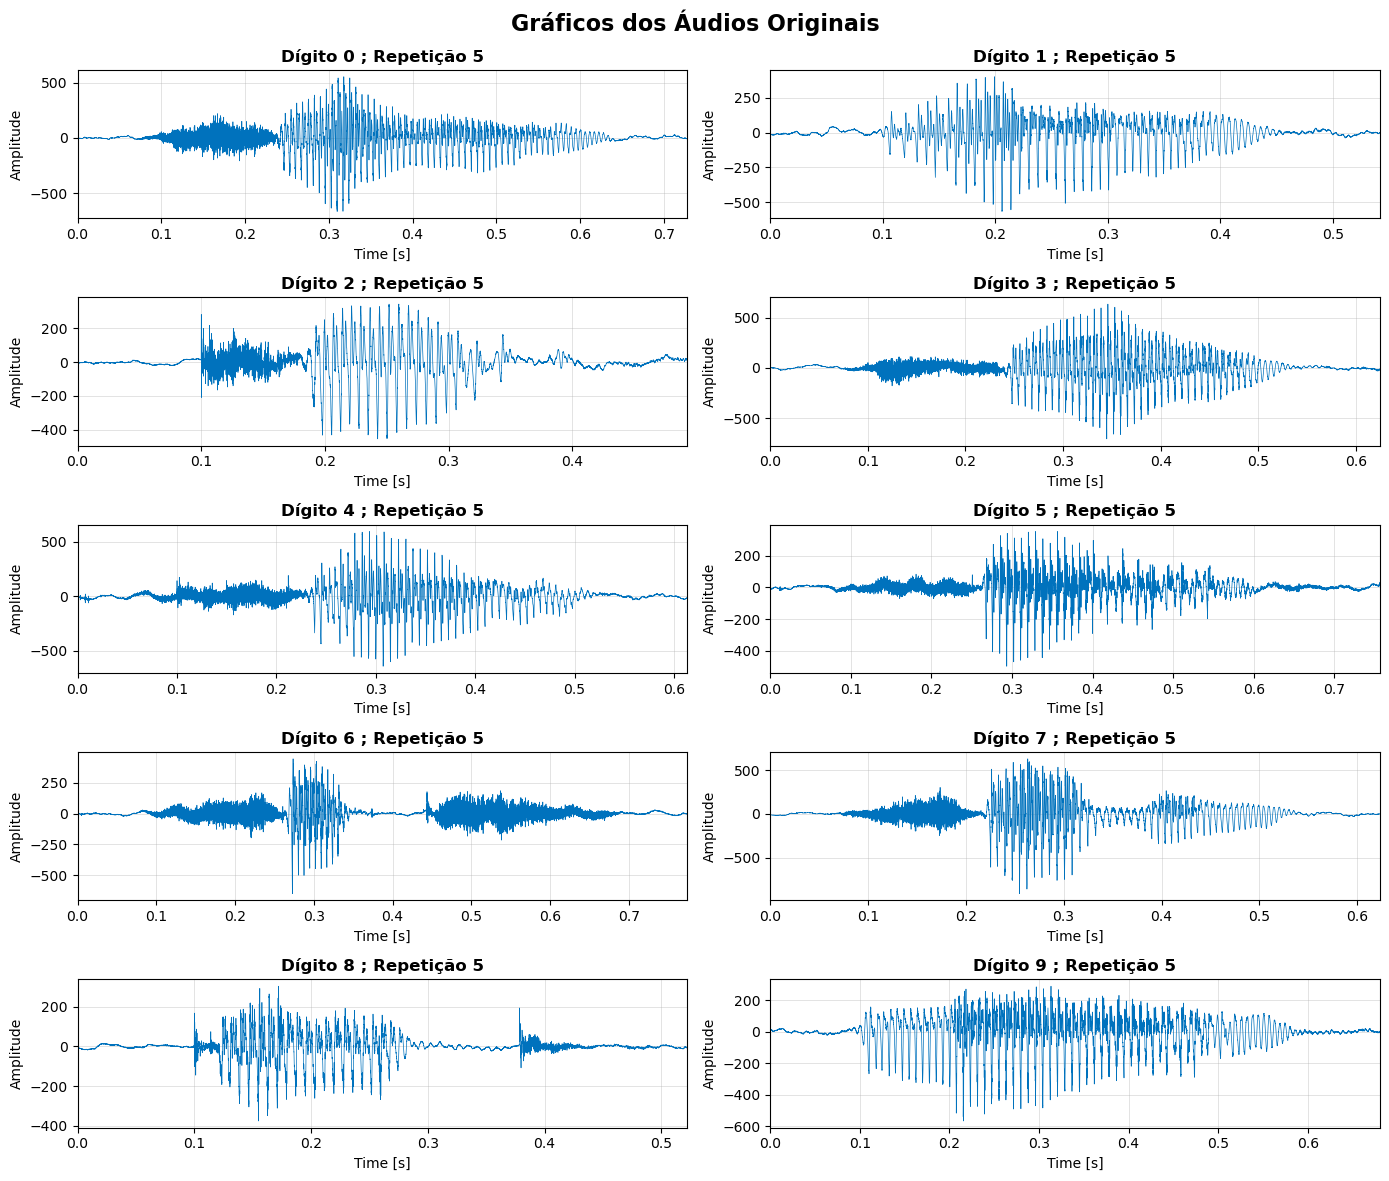

In [5]:
def plotar_sinais_audio(df_dados, coluna_sinal='sinal', titulo='Gráficos dos Áudios', repeticao=5):
    
    df_filtrado = df_dados[df_dados['repeticao'] == repeticao].sort_values(by='digito')
    
    fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(14, 12))
    fig.suptitle(titulo, fontsize=16, fontweight='bold')
    
    axes = axes.flatten()
    
    for i in range(len(axes)):#tambem podemos usar dois loops c/ 5 e 2
        ax=axes[i]
    
        if i < len(df_filtrado):
            linha = df_filtrado.iloc[i]
            sinal = linha[coluna_sinal]
            fs = linha['taxa_amostragem']
            digito = linha['digito']
            repeticao = linha['repeticao']
            
            tempo_segundos = np.arange(len(sinal)) / fs
            
            ax.plot(tempo_segundos, sinal, color='#0072BD', linewidth=0.5) 
            ax.set_title(f'Dígito {digito} ; Repetição {repeticao}', fontsize=12, fontweight='bold')
            ax.set_xlabel('Time [s]')
            ax.set_ylabel('Amplitude')
            ax.grid(True, which='both', linestyle='-', linewidth=0.5, alpha=0.5)
            ax.set_xlim([0, tempo_segundos[-1]])
            
    plt.tight_layout()
    fig.subplots_adjust(top=0.93)
    plt.show()

plotar_sinais_audio(df, 'sinal', 'Gráficos dos Áudios Originais')

In [6]:
def remover_silencio(sinal, razao_limiar=0.05):
    limiar = razao_limiar * np.max(np.abs(sinal))
    i_ativos = np.where(np.abs(sinal) > limiar)[0]
    
    if len(i_ativos) == 0:
        return sinal
    else:
        return sinal[i_ativos[0]:]
    
def normalizar_sinal(sinal): 
    minimo = np.min(sinal)
    maximo = np.max(sinal)
    return  2 * ((sinal - minimo) / (maximo - minimo)) - 1

def pre_processar_sinal(sinal):
    s_silencio = remover_silencio(sinal)
    normalizado = normalizar_sinal(s_silencio)
    return normalizado

In [7]:
s_processados = [pre_processar_sinal(s) for s in df['sinal']]

# adicionar silencio no fim
tamanho_maximo = max(len(s) for s in s_processados)
s_preenchidos = []

for s in s_processados:
    preenchimento = tamanho_maximo - len(s)
    preenchido = np.pad(s, (0, preenchimento), mode='constant', constant_values=0)
    s_preenchidos.append(preenchido)
df['sinal_pre_proc'] = s_preenchidos

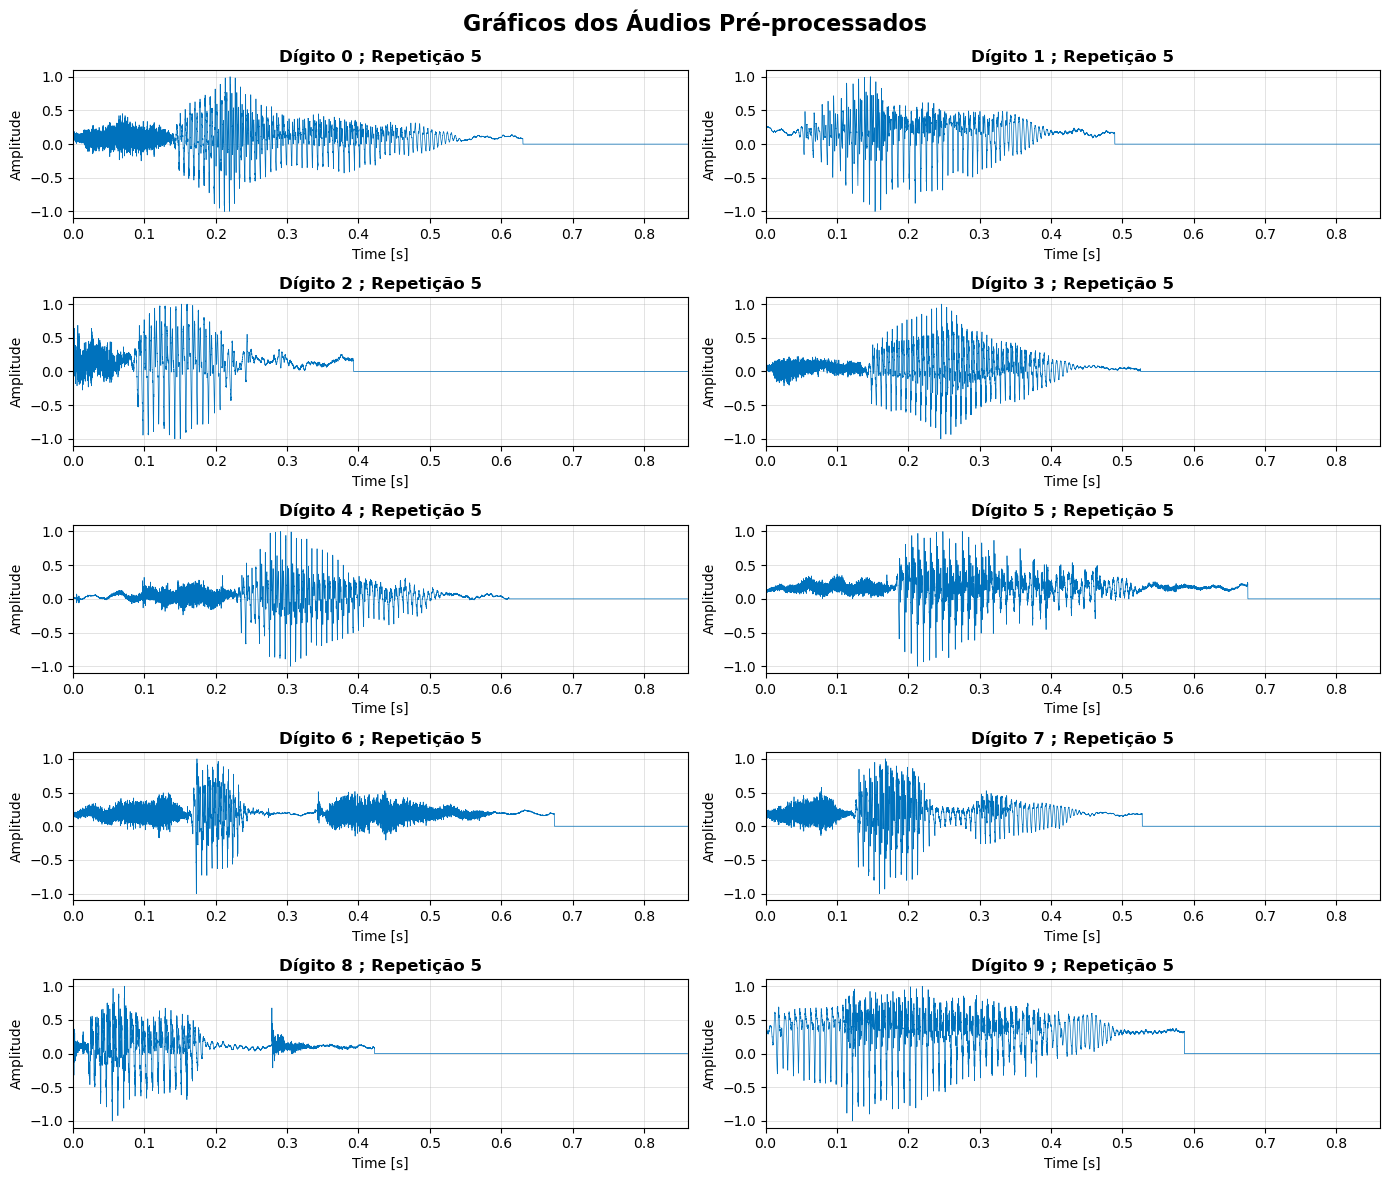

In [8]:
plotar_sinais_audio(df, coluna_sinal='sinal_pre_proc', titulo='Gráficos dos Áudios Pré-processados',repeticao=5)

Comparando os gráficos obtidos no 3 e no 5 constatamos que o processo de pré-processamento eliminou variabilidade irrelevante, garantido o mesmo instante de início do som, a mesma escala de amplitudes, e a mesma duração.

Conseguimos ainda identificar algumas características temporais nos gráficos que poderão ser usadas para distinguir os algarismos. Por exemplo: vemos que o número seis (Six) é um pico sonoro curto, apenas uma sílaba seca. Enquanto o sete (Seven) é constituída por 2 silabas separadas por um pequeno silêncio.


In [ ]:
def energia_total(sinal):
    return np.sum(sinal ** 2)

def cruzamento_zero(sinal):#taxa quantas vezes o sinal cruza 0
    alteracao_sinal = np.diff(np.sign(sinal))
    return np.sum(np.abs(alteracao_sinal))/2

def rms_energia(sinal):#valor eficaz/root mean square
    return np.sqrt(np.mean(sinal **2 ))

def razao_energia(sinal):#1a metade vs 2a metade
    meio = len(sinal)//2
    primeira = np.sum(sinal[:meio]**2)
    segunda = np.sum(sinal[meio:]**2)
    
    if segunda == 0:
        return primeira
    
    return primeira/segunda

df['energia_total']=[energia_total(s) for s in df['sinal_pre_proc']]
df['zcr']=[cruzamento_zero(s) for s in df['sinal_pre_proc']]
df['rms']=[rms_energia(s) for s in df['sinal_pre_proc']]
df['desvio_padrao']=[np.std(s) for s in df['sinal_pre_proc']]
df['razao_energia']=[razao_energia(s) for s in df['sinal_pre_proc']]

print("Características temporais guardadas")
display(df[['digito', 'repeticao', 'energia_total', 'zcr', 'rms', 'desvio_padrao', 'razao_energia']].head())

Características temporais extraídas e guardadas com sucesso!


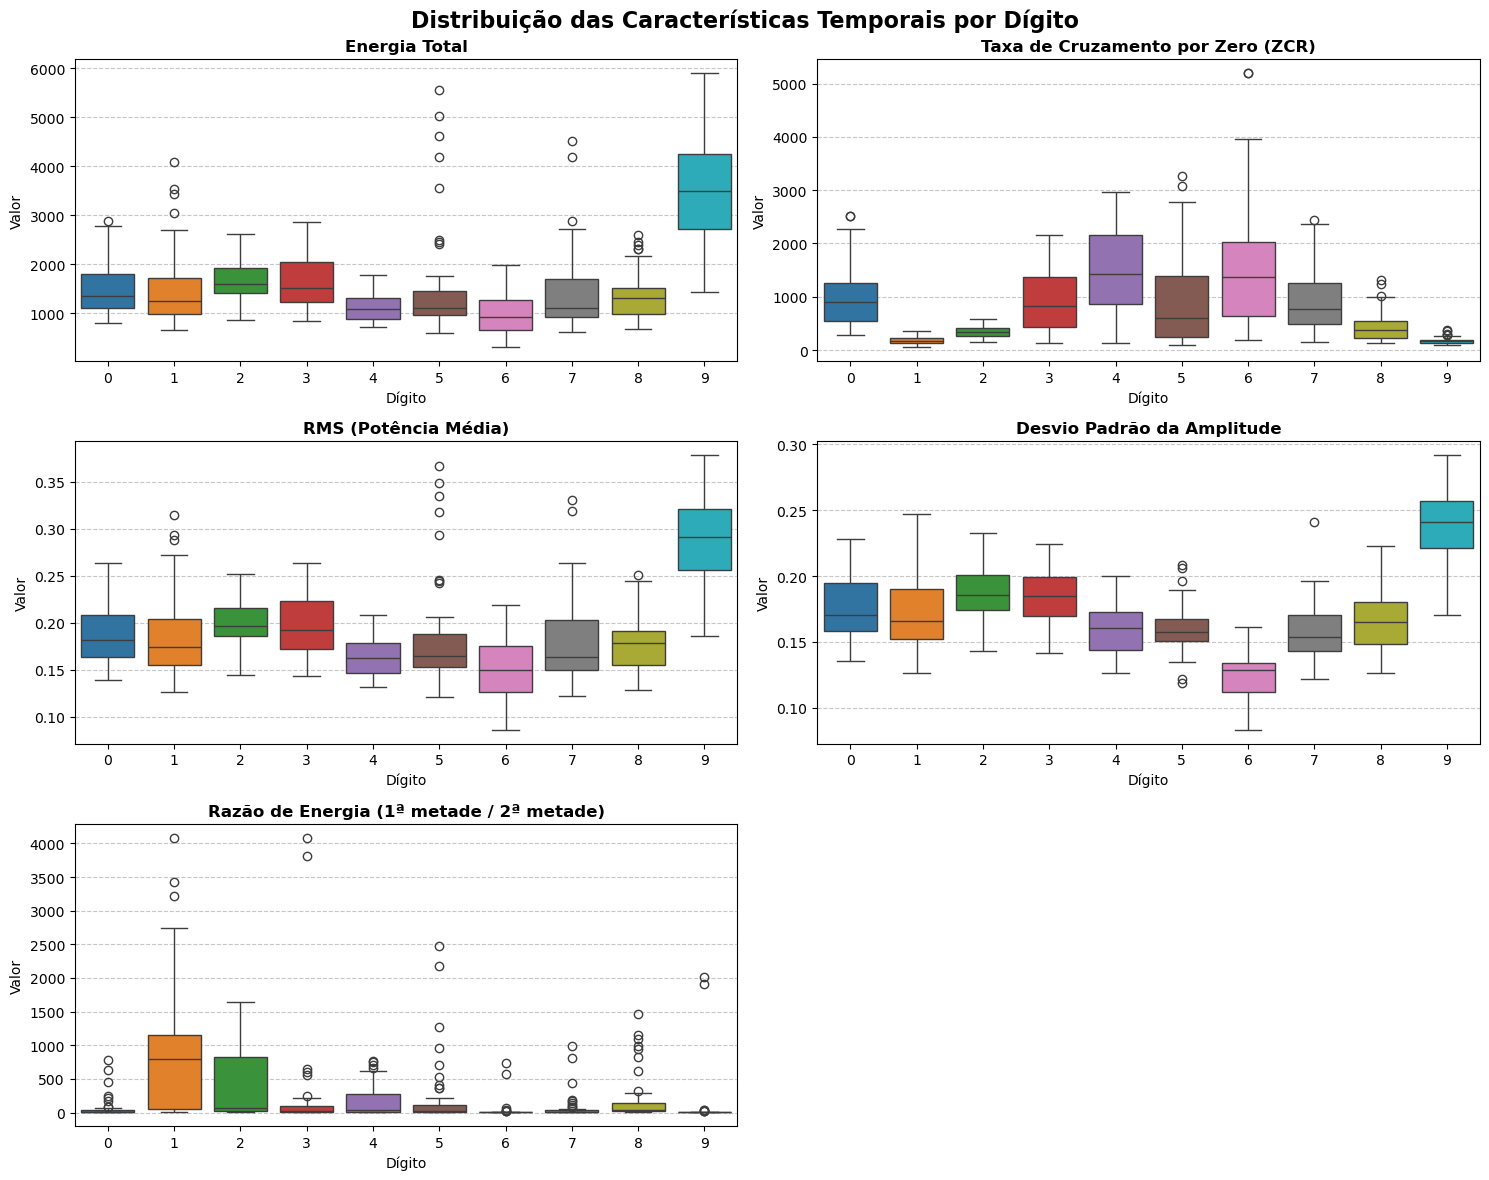

In [10]:
# Lista das 5 características temporais que calculámos no Passo 7
features = ['energia_total', 'zcr', 'rms', 'desvio_padrao', 'razao_energia']
nomes_features = ['Energia Total', 'Taxa de Cruzamento por Zero (ZCR)', 
                  'RMS (Potência Média)', 'Desvio Padrão da Amplitude', 
                  'Razão de Energia (1ª metade / 2ª metade)']

# Definir a paleta de cores para os 10 dígitos
paleta = sns.color_palette("tab10", 10)

# --- 1. Criar a grelha de Boxplots para avaliar individualmente cada feature ---
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 12))    
fig.suptitle('Distribuição das Características Temporais por Dígito', fontsize=16, fontweight='bold')

axes = axes.flatten()

for i in range(len(features)):
    feature = features[i]

    sns.boxplot(x='digito', y=feature, data=df, ax=axes[i],hue='digito', palette=paleta, legend=False)
    axes[i].set_title(nomes_features[i], fontweight='bold')
    axes[i].set_xlabel('Dígito')
    axes[i].set_ylabel('Valor')
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

axes[5].set_visible(False)#plot 3x2(6), só 5 features
plt.tight_layout()
plt.show()

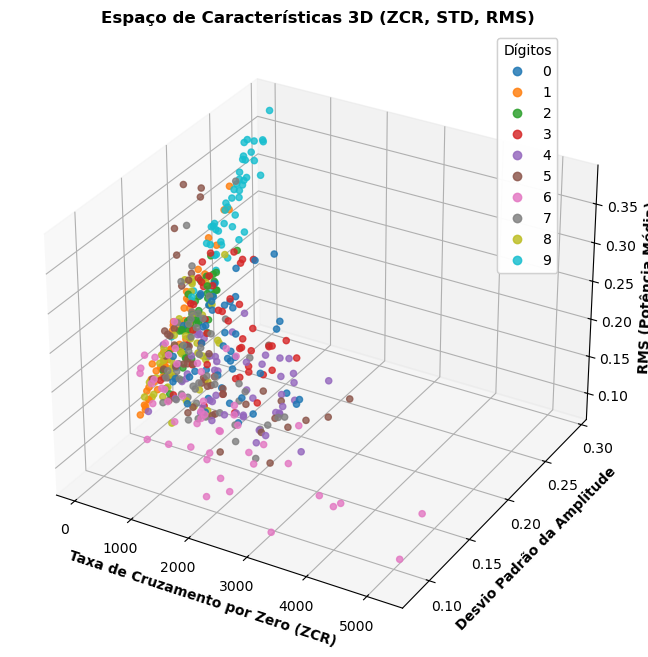

In [11]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

x = df['zcr']
y = df['desvio_padrao']
z = df['rms']

scatter = ax.scatter(x, y, z, c=df['digito'], cmap='tab10', s=20, alpha=0.8)
ax.set_xlabel('Taxa de Cruzamento por Zero (ZCR)', fontweight='bold')
ax.set_ylabel('Desvio Padrão da Amplitude', fontweight='bold')
ax.set_zlabel('RMS (Potência Média)', fontweight='bold')
ax.set_title('Espaço de Características 3D (ZCR, STD, RMS)', fontweight='bold')

legend = ax.legend(*scatter.legend_elements(), title="Dígitos", bbox_to_anchor=(0.9, 1))
ax.add_artist(legend)

plt.show()

Coefecientes guardados na coluna 'fft_coefs'


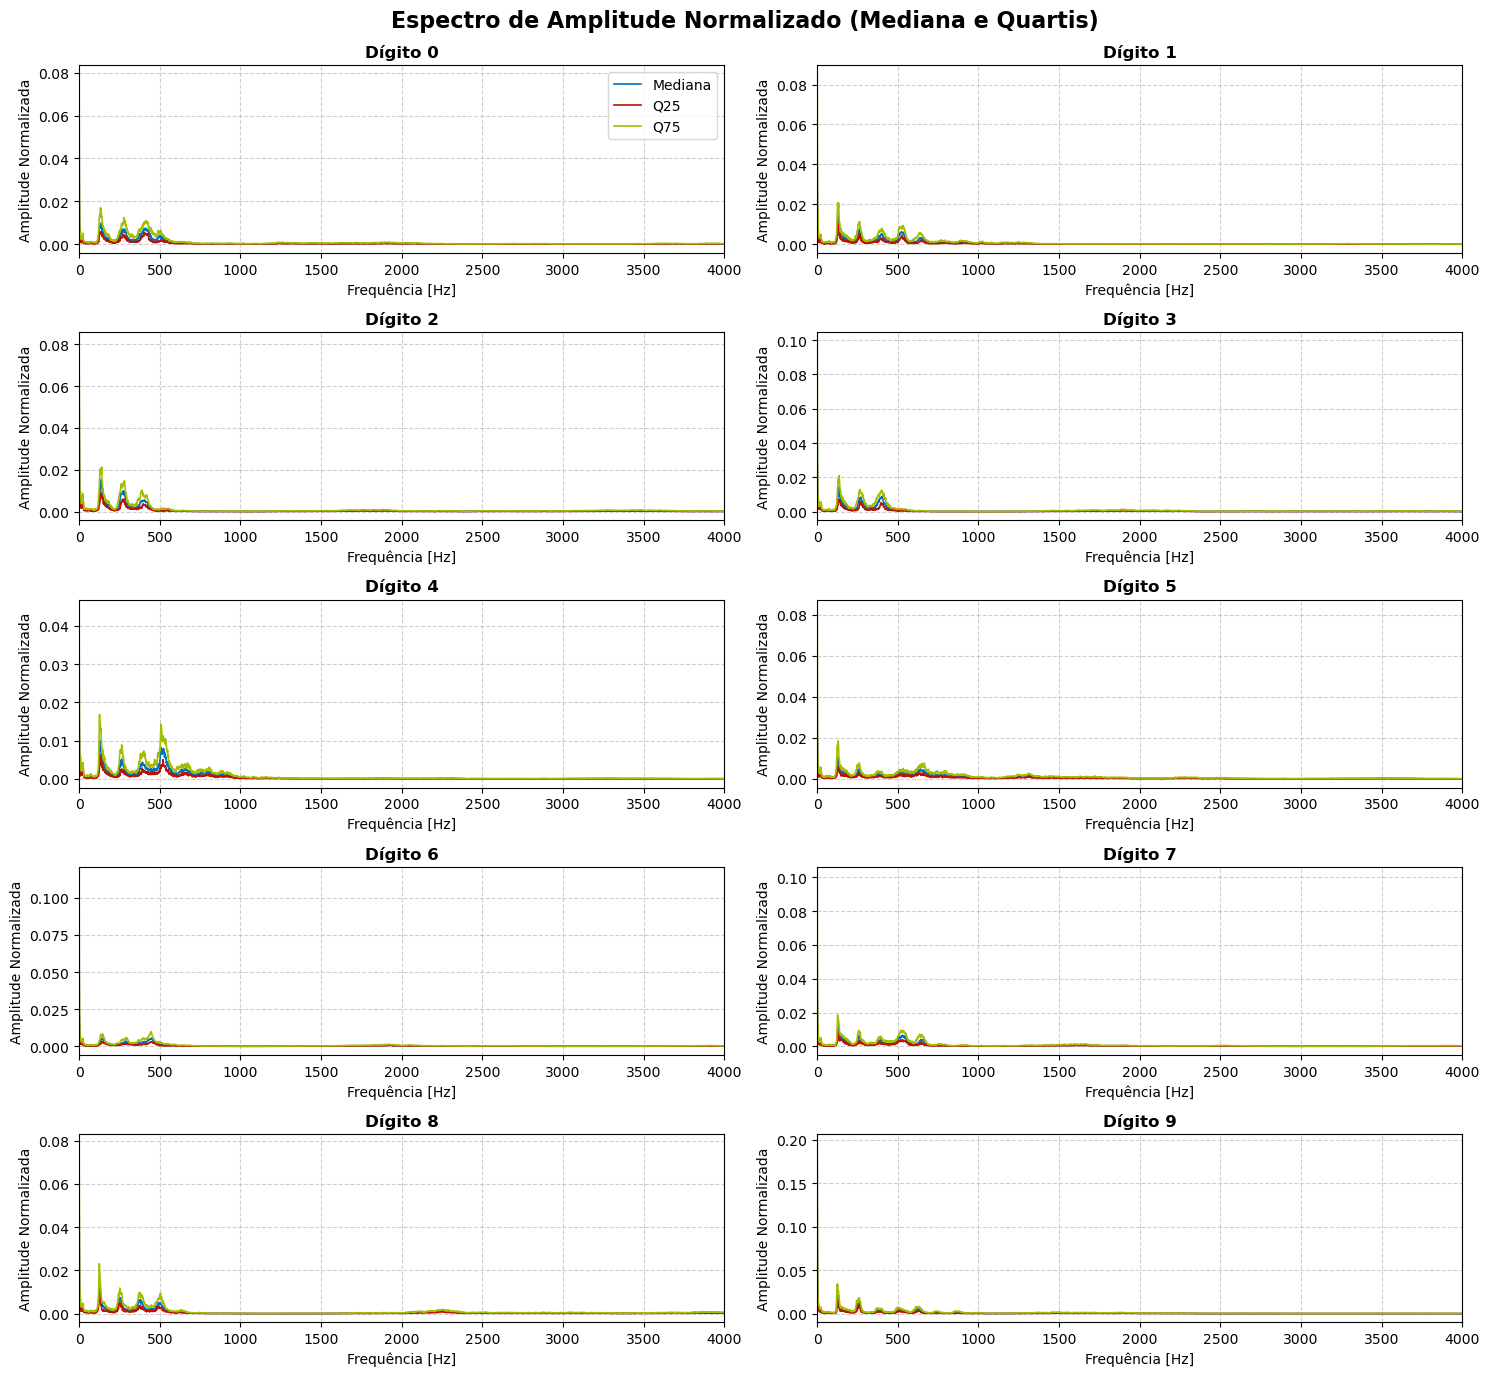

In [12]:

df['fft_coefs']=[np.fft.fft(s) for s in df['sinal_pre_proc']]
print("Coefecientes guardados na coluna 'fft_coefs'")
#display(df[['digito', 'repeticao', 'fft_coefs']].head())

N = len(df['sinal_pre_proc'].iloc[0])
fs = df['taxa_amostragem'].iloc[0]
meio_N = N//2
eixo_freqs = np.linspace(0 ,fs/2, meio_N)

fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(15, 14))
fig.suptitle('Espectro de Amplitude Normalizado (Mediana e Quartis)', fontsize=16, fontweight='bold')
axes = axes.flatten()

stats_espectrais = {}

for digito in range(10):
    df_digito = df[df['digito']==digito]
    
    espetros_pos=[]
    for fft_array in df_digito['fft_coefs']:
        amplitude = np.abs(fft_array)/N
        espetros_pos.append(amplitude[:meio_N])
        
    matriz_espetros = np.array(espetros_pos)
    
    q1=np.quantile(matriz_espetros, 0.25, axis=0)
    mediana=np.quantile(matriz_espetros, 0.5, axis=0)
    q3=np.quantile(matriz_espetros, 0.75, axis=0)
    
    stats_espectrais[digito] = {'q1':q1, 'mediana':mediana, 'q3': q3}
    
    ax = axes[digito]
    
    ax.plot(eixo_freqs, mediana, color='#0072BD', linewidth=1.2, label='Mediana')    
    ax.plot(eixo_freqs, q1, color="#BD1300", linewidth=1.2, label='Q25')  
    ax.plot(eixo_freqs, q3, color="#A4BD00", linewidth=1.2, label='Q75')  
    
    ax.set_title(f'Dígito {digito}', fontweight='bold')
    ax.set_xlabel('Frequência [Hz]')
    ax.set_ylabel('Amplitude Normalizada')
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.set_xlim([0, 4000])
    
    if digito == 0:
        ax.legend()

plt.tight_layout()
fig.subplots_adjust(top=0.94)
plt.show()

In [13]:
freq_dominante = []
amp_max_espetral = []
media_espetral = []
centroide_espetral = []
edge_freq_espetral = []

for fft_array in df['fft_coefs']:
    amp_norm=np.abs(fft_array[:meio_N])/N
    
    indice_max = np.argmax(amp_norm)
    freq_dominante.append(eixo_freqs[indice_max])
    amp_max_espetral.append(amp_norm[indice_max])
    
    media_espetral.append(np.mean(amp_norm))
    
    total_amp = np.sum(amp_norm)
    if total_amp == 0:
        centroide= 0
    else:
        centroide = np.sum(eixo_freqs*amp_norm)/total_amp
    centroide_espetral.append(centroide)
    
    energia_acumulada = np.cumsum(amp_norm ** 2)
    energia_total = energia_acumulada[-1]
    
    indice_edge = np.where(energia_acumulada >= 0.95*energia_total)[0][0]
    edge_freq_espetral.append(eixo_freqs[indice_edge])
    
df['freq_dominante'] = freq_dominante
df['amp_max_espectral'] = amp_max_espetral
df['media_espectral'] = media_espetral
df['centroide_espectral'] = centroide_espetral
df['spectral_edge_freq'] = edge_freq_espetral

print("As 5 características espectrais foram calculadas e adicionadas à estrutura de dados.")
#display(df[['digito', 'freq_dominante', 'amp_max_espectral', 'media_espectral', 'centroide_espectral', 'spectral_edge_freq']].head())
#display(df.head())

As 5 características espectrais foram calculadas e adicionadas à estrutura de dados.


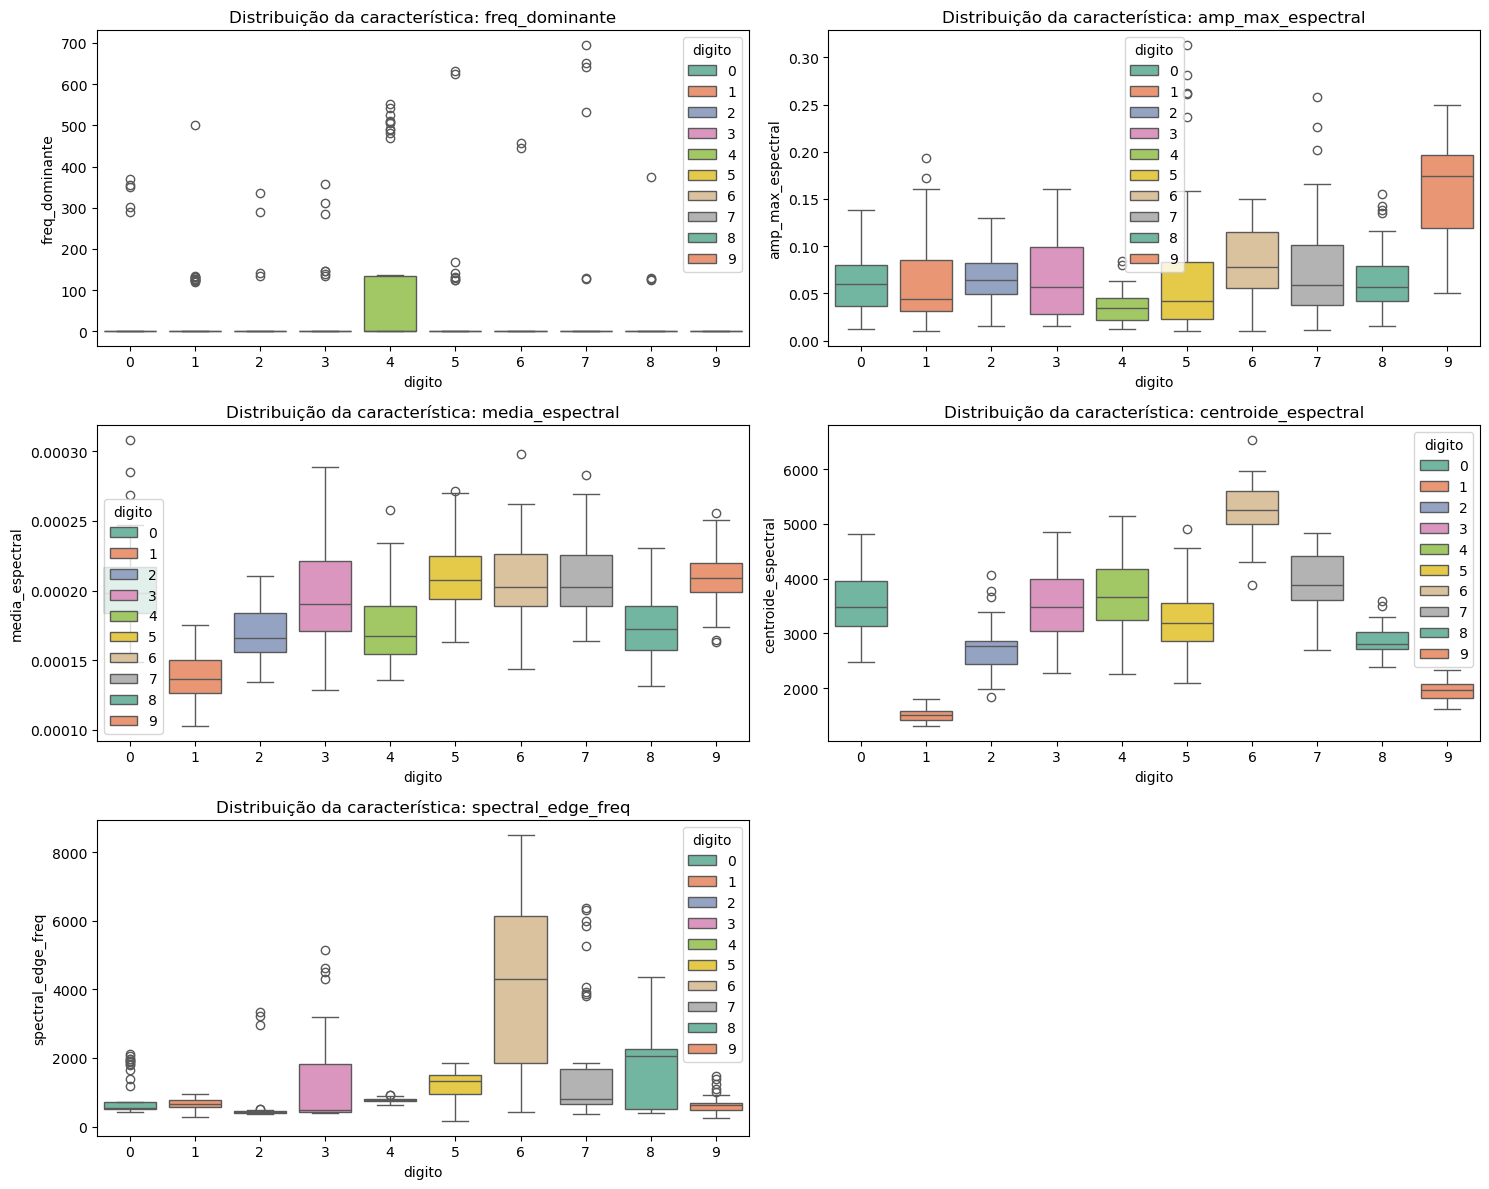

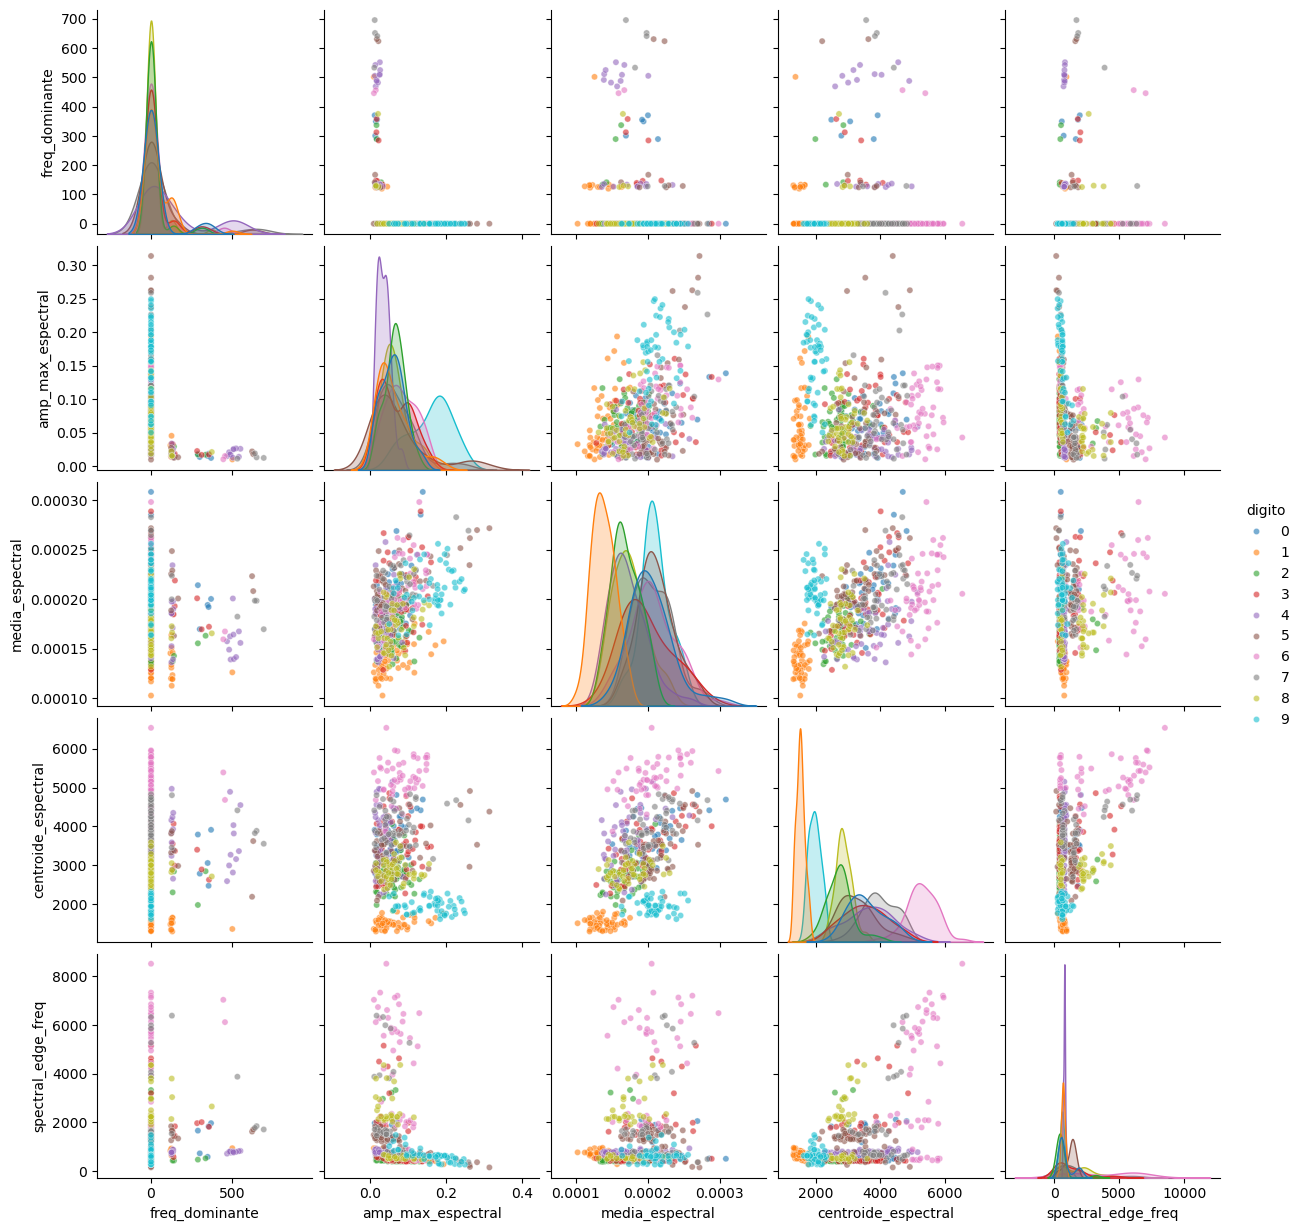

In [14]:
# Lista de características a testar (agora são 5)
features_para_testar = ['freq_dominante','amp_max_espectral','media_espectral','centroide_espectral','spectral_edge_freq'] 

colunas_para_plot = ['digito'] + features_para_testar
df_plot = df[colunas_para_plot].copy()


#distribuicao individual
plt.figure(figsize=(15, 12))

for i in range(len(features_para_testar)):
    feature=features_para_testar[i]

    plt.subplot(3, 2, i+1)
    sns.boxplot(x='digito', y=feature, data=df_plot, palette='Set2', hue='digito')
    plt.title(f'Distribuição da característica: {feature}')

plt.tight_layout()
plt.savefig('boxplots_caracteristicas.png')
plt.show()


#compara aos pares
sns.pairplot(df_plot, hue='digito', vars=features_para_testar, palette='tab10', 
             plot_kws={'alpha':0.6, 's':20})
plt.savefig('pairplot_2d.png')
plt.show()


Centroide_Espectral vemos os 

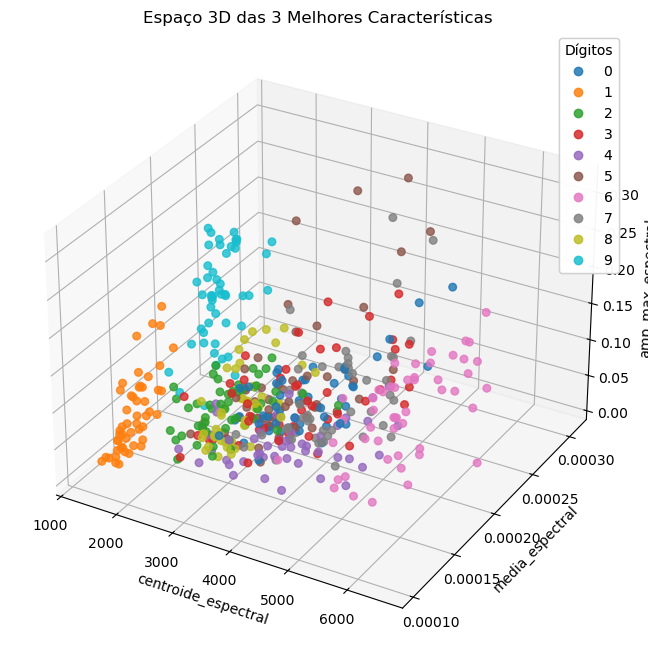

In [15]:
#grafico 3d, comparar 3 carateristicas escolhidas
f1 = 'centroide_espectral'
f2 = 'media_espectral'
f3 = 'amp_max_espectral'

cores = pd.Categorical(df_plot['digito']).codes

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(df_plot[f1], df_plot[f2], df_plot[f3], 
                     c=cores, cmap='tab10', s=30, alpha=0.8)

ax.set_xlabel(f1)
ax.set_ylabel(f2)
ax.set_zlabel(f3)
ax.set_title('Espaço 3D das 3 Melhores Características')

# adicionar legenda
handles, labels = scatter.legend_elements()
legend1 = ax.legend(handles,labels, title="Dígitos")
ax.add_artist(legend1)

plt.savefig('grafico_3d_melhores.png')
plt.show()

In [16]:
colunas_para_remover = ['sinal', 'sinal_pre_proc', 'fft_coefs']
df_limpo = df.drop(columns=colunas_para_remover)
print(f"Sinais de áudio removidos com sucesso.")

dados_mat = {col: df_limpo[col].values for col in df_limpo.columns}

nome_ficheiro_mat = 'caracteristicas_extraidas_meta1.mat'
sio.savemat(nome_ficheiro_mat, {'dados_meta1': dados_mat})

print(f"Estrutura de dados guardada no ficheiro '{nome_ficheiro_mat}' pronta para a Meta 2!")
#display(df_limpo.head())

Sinais de áudio removidos com sucesso.
Estrutura de dados guardada no ficheiro 'caracteristicas_extraidas_meta1.mat' pronta para a Meta 2!
